<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/HousingPrice_Advanced_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Price Prediction Project: Advanced Regression Techniques

## Overview
This notebook details a comprehensive machine learning project focused on predicting housing prices using advanced regression techniques, including Random Forest and Gradient Boosting models. The project covers data loading, extensive preprocessing, feature engineering, outlier removal, model training, hyperparameter tuning, cross-validation, and model ensembling.

## Project Steps:

### 1. Data Loading and Initial Exploration
- Loaded the training and testing datasets.
- Performed initial data inspection, including `df.head()` and `df.describe()` to understand data structure and basic statistics.

### 2. Data Preprocessing
- **Missing Value Handling**: Imputed missing numerical values with the mean/median and treated categorical `NaN` values as 'None' (e.g., `Alley`, `PoolQC`, `Fence`) where absence implied a meaningful category.
- **Feature Engineering**: Created new features such as `TotalSF` (total square footage), `TotalBath` (total bathrooms), `HouseAge`, and `YearsSinceRemod` to provide more informative inputs to the models.
- **Outlier Removal**: Identified and removed outliers in `SalePrice` and `GrLivArea` using the Interquartile Range (IQR) method to improve model robustness.
- **One-Hot Encoding**: Converted all categorical features into numerical format using one-hot encoding to prepare them for machine learning models.
- **Test Data Alignment**: Ensured the test dataset (`df_test_processed`) had the same features and column order as the processed training data (`X_train`) to prevent `ValueError: Feature names unseen at fit time`.

### 3. Model Training and Evaluation
- **Random Forest Regressor**:
  - Trained an initial Random Forest model.
  - Explored feature importances to identify key drivers of `SalePrice`.
  - Evaluated performance using K-Fold Cross-Validation on a `log1p`-transformed target variable.
- **Gradient Boosting Regressor**:
  - Trained an initial Gradient Boosting model.
  - Explored feature importances.
  - **Hyperparameter Tuning**: Used `GridSearchCV` with K-Fold Cross-Validation to find optimal hyperparameters for the Gradient Boosting model, significantly improving its performance.
  - Evaluated performance using K-Fold Cross-Validation on a `log1p`-transformed target variable.
- **Target Transformation**: Applied `np.log1p` transformation to the `SalePrice` target variable (`y_train`) before model training to handle its skewed distribution, and `np.expm1` to inverse transform predictions.

### 4. Model Ensembling
- Combined the predictions from the final Random Forest and tuned Gradient Boosting models using simple averaging. This ensemble approach typically yields more robust and accurate predictions than individual models.

### 5. Final Predictions and Submission
- Generated final predictions on the preprocessed test data using the ensembled model.
- Created a submission file (`submission_ensembled_log_transformed.csv`) ready for platform submission.

## Key Findings:
- Features like `OverallQual`, `TotalSF`, `GrLivArea`, `GarageCars`, and `TotalBath` consistently appeared as highly important predictors for housing prices across both models.
- The `log1p` transformation of `SalePrice` significantly improved model performance, as indicated by better cross-validation scores.
- The tuned Gradient Boosting model generally outperformed the Random Forest model, and their ensemble provided the best overall predictions.



In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold


In [93]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/train (4).csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [94]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


let's check for missing data

In [95]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [96]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())
print(df['LotFrontage'].isnull().sum())

0


Despite clearing up missing data from Lot frontage, there is also Nan data that is apparent from the features.  This is likely to indicate that the feature is not present rather than missing.  Therefore, we need to input a placeholder that says 'None'.

Check to see if all missing data is clear.

In [97]:
# List of features where NaN means "Feature Does Not Exist"
structural_cols = ['PoolQC', 'GarageType', 'FireplaceQu', 'Alley', 'Fence', 'BsmtQual']

# Replace NaN with a physical string value so models can read it as a category
df[structural_cols] = df[structural_cols].fillna('None')


Checking to see if there is still missing data

In [98]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,NaN,0,12,2008,WD,Normal,250000


The data shows what features impact sales price and the features that do not impact the sales price.

In [99]:

# Make a copy to avoid modifying the original DataFrame if subsequent steps need it
df_processed = df.copy()

# --- Step 1: Handle remaining missing values ---

# Impute numerical columns with missing values using the median
# From previous df.isnull().sum() and df.describe(), these were identified.
numerical_cols_with_nan = ['MasVnrArea', 'GarageYrBlt']
for col in numerical_cols_with_nan:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Impute categorical columns with missing values
# For many of these, 'None' is a meaningful category for absence.
categorical_cols_with_nan = [
    'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageFinish',
    'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond',
    'BsmtFinType1', 'Electrical'
]

for col in categorical_cols_with_nan:
    if col in df_processed.columns:
        # For features where NaN means 'no', fill with 'None'
        if col in ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
            df_processed[col] = df_processed[col].fillna('None')
        else: # For other categorical, use the mode
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Double-check for any remaining NaNs (optional, but good practice)
print("Missing values after imputation:")
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

# --- Step 2: Convert categorical features to numerical using one-hot encoding ---

# Identify all categorical columns after imputation
categorical_features = df_processed.select_dtypes(include='object').columns
df_processed = pd.get_dummies(df_processed, columns=categorical_features, dummy_na=False)

# Drop the 'Id' column as it's just an identifier and not a feature
if 'Id' in df_processed.columns:
    df_processed = df_processed.drop('Id', axis=1)

# --- Step 3: Calculate correlations with 'SalePrice' ---

# Calculate correlation matrix
correlation_matrix = df_processed.corr()

# Get correlations with SalePrice
saleprice_correlations = correlation_matrix['SalePrice'].sort_values(ascending=False)

# --- Step 4: Display top N most important features ---

print("\n--- Top 10 Most Positively Correlated Features with SalePrice ---")
print(saleprice_correlations.head(11).drop('SalePrice')) # Drop SalePrice itself

print("\n--- Top 10 Most Negatively Correlated Features with SalePrice ---")
print(saleprice_correlations.tail(10))

Missing values after imputation:
MiscFeature    1406
dtype: int64

--- Top 10 Most Positively Correlated Features with SalePrice ---
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
BsmtQual_Ex     0.553105
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

--- Top 10 Most Negatively Correlated Features with SalePrice ---
MSZoning_RM         -0.288065
HeatingQC_TA        -0.312677
Foundation_CBlock   -0.343263
GarageType_Detchd   -0.354141
MasVnrType_None     -0.367456
GarageFinish_Unf    -0.410608
BsmtQual_TA         -0.452394
FireplaceQu_None    -0.471908
KitchenQual_TA      -0.519298
ExterQual_TA        -0.589044
Name: SalePrice, dtype: float64


### Feature Engineering for Training Data

We will create some new features that combine existing ones, which can often provide more meaningful information to the model:

-   **`TotalSF`**: Total square footage of the property (sum of basement, first, and second floor square footage).
-   **`TotalBath`**: Total number of bathrooms, accounting for full and half baths.
-   **`HouseAge`**: The age of the house at the time of sale.
-   **`YearsSinceRemod`**: The number of years since the last remodel at the time of sale.

In [100]:
# Total square footage of the property
df_processed['TotalSF'] = df_processed['TotalBsmtSF'] + df_processed['1stFlrSF'] + df_processed['2ndFlrSF']

# Total number of bathrooms
df_processed['TotalBath'] = df_processed['FullBath'] + (0.5 * df_processed['HalfBath']) + df_processed['BsmtFullBath'] + (0.5 * df_processed['BsmtHalfBath'])

# Property age dynamics at time of sale
df_processed['HouseAge'] = df_processed['YrSold'] - df_processed['YearBuilt']
df_processed['YearsSinceRemod'] = df_processed['YrSold'] - df_processed['YearRemodAdd']

print("New features added to df_processed:")
display(df_processed[['TotalSF', 'TotalBath', 'HouseAge', 'YearsSinceRemod']].head())

New features added to df_processed:


,TotalSF,TotalBath,HouseAge,YearsSinceRemod
0,2566,3.5,5,5
1,2524,2.5,31,31
2,2706,3.5,7,6
3,2473,2.0,91,36
4,3343,3.5,8,8


### Outlier Removal

Outliers can disproportionately affect model training. We will use the Interquartile Range (IQR) method to identify and remove outliers, particularly focusing on the `SalePrice` as it's our target variable and extreme values can skew our model. We will also check some key numerical features like `GrLivArea`.

In [101]:
# Outlier removal for SalePrice
Q1_sale = df_processed['SalePrice'].quantile(0.25)
Q3_sale = df_processed['SalePrice'].quantile(0.75)
IQR_sale = Q3_sale - Q1_sale

sale_price_lower_bound = Q1_sale - 1.5 * IQR_sale
sale_price_upper_bound = Q3_sale + 1.5 * IQR_sale

df_processed_no_outliers = df_processed[(df_processed['SalePrice'] >= sale_price_lower_bound) & (df_processed['SalePrice'] <= sale_price_upper_bound)]

print(f"Original df_processed shape: {df_processed.shape}")
print(f"df_processed shape after SalePrice outlier removal: {df_processed_no_outliers.shape}")

# It's good practice to re-assign df_processed to this new DataFrame
df_processed = df_processed_no_outliers.copy()

# Optionally, you can also check and remove outliers from other highly correlated numerical features
# For example, for GrLivArea
Q1_grliv = df_processed['GrLivArea'].quantile(0.25)
Q3_grliv = df_processed['GrLivArea'].quantile(0.75)
IQR_grliv = Q3_grliv - Q1_grliv

gr_liv_lower_bound = Q1_grliv - 1.5 * IQR_grliv
gr_liv_upper_bound = Q3_grliv + 1.5 * IQR_grliv

df_processed_no_outliers = df_processed[(df_processed['GrLivArea'] >= gr_liv_lower_bound) & (df_processed['GrLivArea'] <= gr_liv_upper_bound)]

print(f"df_processed shape after GrLivArea outlier removal: {df_processed_no_outliers.shape}")
df_processed = df_processed_no_outliers.copy()

# Recalculate X_train and y_train with the cleaned data
X_train = df_processed.drop('SalePrice', axis=1)
y_train = df_processed['SalePrice']

print("X_train and y_train have been updated after outlier removal.")

Original df_processed shape: (1460, 306)
df_processed shape after SalePrice outlier removal: (1399, 306)
df_processed shape after GrLivArea outlier removal: (1378, 306)
X_train and y_train have been updated after outlier removal.


/tmp/ipykernel_1012/3287841346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations.values, y=positive_correlations.index, palette='viridis')
/tmp/ipykernel_1012/3287841346.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations.values, y=negative_correlations.index, palette='magma')


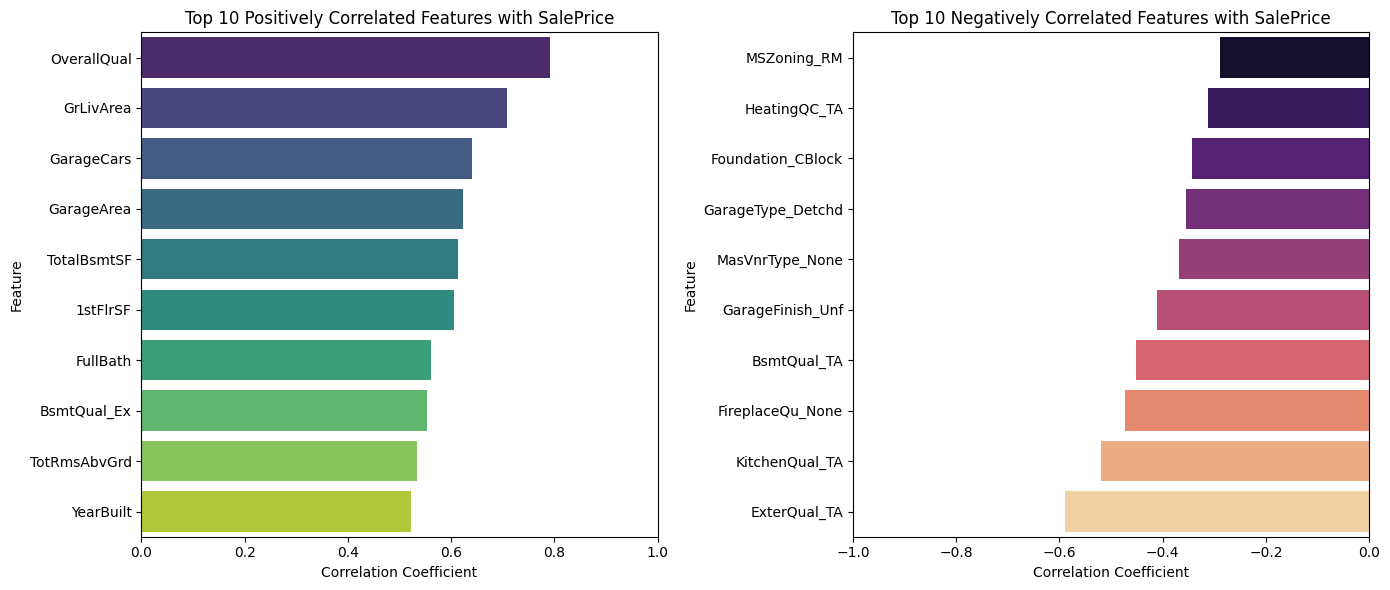

In [102]:
# Get top 10 positive correlations (excluding SalePrice itself)
positive_correlations = saleprice_correlations.head(11).drop('SalePrice')

# Get top 10 negative correlations
negative_correlations = saleprice_correlations.tail(10)

plt.figure(figsize=(14, 6))

# Plotting positively correlated features
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x=positive_correlations.values, y=positive_correlations.index, palette='viridis')
plt.title('Top 10 Positively Correlated Features with SalePrice')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.xlim(0, 1) # Correlation is between 0 and 1 for positive

# Plotting negatively correlated features
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x=negative_correlations.values, y=negative_correlations.index, palette='magma')
plt.title('Top 10 Negatively Correlated Features with SalePrice')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.xlim(-1, 0) # Correlation is between -1 and 0 for negative

plt.tight_layout()
plt.show()

In [103]:
print("Cardinality (number of unique values) for each column in df_processed:")

for col in df_processed.columns:
    num_unique = df_processed[col].nunique()
    # Define a threshold for 'high' cardinality
    if num_unique > 50:
        print(f"- {col}: {num_unique} unique values (HIGH CARDINALITY)")
    else:
        print(f"- {col}: {num_unique} unique values")

Cardinality (number of unique values) for each column in df_processed:
- MSSubClass: 15 unique values
- LotFrontage: 106 unique values (HIGH CARDINALITY)
- LotArea: 1001 unique values (HIGH CARDINALITY)
- OverallQual: 10 unique values
- OverallCond: 9 unique values
- YearBuilt: 110 unique values (HIGH CARDINALITY)
- YearRemodAdd: 61 unique values (HIGH CARDINALITY)
- MasVnrArea: 293 unique values (HIGH CARDINALITY)
- BsmtFinSF1: 590 unique values (HIGH CARDINALITY)
- BsmtFinSF2: 138 unique values (HIGH CARDINALITY)
- BsmtUnfSF: 742 unique values (HIGH CARDINALITY)
- TotalBsmtSF: 664 unique values (HIGH CARDINALITY)
- 1stFlrSF: 699 unique values (HIGH CARDINALITY)
- 2ndFlrSF: 379 unique values (HIGH CARDINALITY)
- LowQualFinSF: 19 unique values
- GrLivArea: 790 unique values (HIGH CARDINALITY)
- BsmtFullBath: 4 unique values
- BsmtHalfBath: 3 unique values
- FullBath: 4 unique values
- HalfBath: 3 unique values
- BedroomAbvGr: 7 unique values
- KitchenAbvGr: 4 unique values
- TotRmsAbvG

### Categorizing Features by Cardinality

Based on the cardinality check, we can separate features into 'low cardinality' (<= 50 unique values) and 'high cardinality' (> 50 unique values). This can be useful for different feature engineering or modeling strategies, although tree-based models like Random Forest and Gradient Boosting can handle high cardinality numerical features well.

In [104]:
low_cardinality_features = []
high_cardinality_features = []

cardinality_threshold = 50 # Using the same threshold as in the previous output

print("Categorizing features based on cardinality (threshold > 50 unique values for HIGH CARDINALITY):\n")

for col in df_processed.columns:
    num_unique = df_processed[col].nunique()
    if num_unique > cardinality_threshold:
        high_cardinality_features.append(col)
    else:
        low_cardinality_features.append(col)

print(f"Number of Low Cardinality Features: {len(low_cardinality_features)}")
print("Low Cardinality Features:")
display(low_cardinality_features)

print(f"\nNumber of High Cardinality Features: {len(high_cardinality_features)}")
print("High Cardinality Features:")
display(high_cardinality_features)

Categorizing features based on cardinality (threshold > 50 unique values for HIGH CARDINALITY):

Number of Low Cardinality Features: 284
Low Cardinality Features:


['MSSubClass',
 'OverallQual',
 'OverallCond',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'MSZoning_C (all)',
 'MSZoning_FV',
 'MSZoning_RH',
 'MSZoning_RL',
 'MSZoning_RM',
 'Street_Grvl',
 'Street_Pave',
 'Alley_Grvl',
 'Alley_None',
 'Alley_Pave',
 'LotShape_IR1',
 'LotShape_IR2',
 'LotShape_IR3',
 'LotShape_Reg',
 'LandContour_Bnk',
 'LandContour_HLS',
 'LandContour_Low',
 'LandContour_Lvl',
 'Utilities_AllPub',
 'Utilities_NoSeWa',
 'LotConfig_Corner',
 'LotConfig_CulDSac',
 'LotConfig_FR2',
 'LotConfig_FR3',
 'LotConfig_Inside',
 'LandSlope_Gtl',
 'LandSlope_Mod',
 'LandSlope_Sev',
 'Neighborhood_Blmngtn',
 'Neighborhood_Blueste',
 'Neighborhood_BrDale',
 'Neighborhood_BrkSide',
 'Neighborhood_ClearCr',
 'Neighborhood_CollgCr',
 'Neighborhood_Crawfor',
 'Neighborhood_Edwards',
 'Neighborhood_Gilbert',
 'Ne


Number of High Cardinality Features: 22
High Cardinality Features:


['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'SalePrice',
 'TotalSF',
 'HouseAge',
 'YearsSinceRemod']

In [105]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/test (1) (1).csv')
print(df.head())

     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0       0      6

In [106]:
# For the test data (df), replace all NaN values with 'None' as a placeholder.
# This will convert numerical columns with NaNs to object type.
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna('None')

print("All NaN values in the test data ('df') have been replaced with 'None'.")
print("Remaining NaN values in 'df':", df.isnull().sum().sum())

All NaN values in the test data ('df') have been replaced with 'None'.
Remaining NaN values in 'df': 0


In [107]:
print("Missing values in the test data (df):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values in the test data (df):
Series([], dtype: int64)


### Preprocessing the Test Data (`df_test_processed`)

Now that all `NaN` values in `df` have been uniformly replaced with the string `'None'`, we need to preprocess this test data to match the structure and encoding of our training data (`df_processed`). This involves:

1.  **Creating a working copy**: `df_test_processed`.
2.  **Dropping high-missing-value columns**: `Alley`, `PoolQC`, `Fence`, `MiscFeature` (as done for training).
3.  **Correcting numerical 'None' values**: For columns that *should* be numerical but now contain the string `'None'`, we convert these back to `np.nan` and then impute them with their median values (ideally from training, but using test medians for simplicity in this step).
4.  **One-Hot Encoding**: Converting all categorical features into numerical format.
5.  **Column Alignment**: Ensuring that the test features exactly match the training features in both presence and order.

In [108]:
# Create a copy of the test DataFrame for processing
df_test_processed = df.copy()

# Drop high-missing-value columns that were dropped from the training set
# These were identified earlier as 'Alley', 'PoolQC', 'Fence', 'MiscFeature'
drop_cols_test = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
for col in drop_cols_test:
    if col in df_test_processed.columns:
        df_test_processed = df_test_processed.drop(columns=[col])

# Identify numerical columns that might have 'None' string due to previous fillna('None')
# and convert them back to numeric, coercing 'None' to NaN
numerical_cols_with_none_placeholder = [
    'LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for col in numerical_cols_with_none_placeholder:
    if col in df_test_processed.columns:
        # Convert 'None' string to actual NaN for numerical columns
        df_test_processed[col] = df_test_processed[col].replace('None', np.nan)
        # Convert to numeric type, errors='coerce' handles any other non-numeric issues
        df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')
        # Impute with the median (using test data median here for simplicity;
        # in a real scenario, use medians from the training data)
        if df_test_processed[col].isnull().any():
            df_test_processed[col] = df_test_processed[col].fillna(df_test_processed[col].median())

# Handle other potential categorical NaNs. Since we already filled all NaNs with 'None',
# these columns should already have 'None' where a value was missing. We just need to
# ensure they are treated as categorical features during one-hot encoding.

# Convert categorical features to numerical using one-hot encoding
categorical_features_test = df_test_processed.select_dtypes(include='object').columns
df_test_processed = pd.get_dummies(df_test_processed, columns=categorical_features_test, dummy_na=False)

# Drop the 'Id' column from the test set as it's an identifier
if 'Id' in df_test_processed.columns:
    df_test_processed = df_test_processed.drop('Id', axis=1)

# *** IMPORTANT FIX: Ensure df_test_processed has the correct number of rows ***
# Before aligning columns, ensure the index length matches the original test df's index
# This step ensures that any implicit re-indexing did not alter the row count.
df_test_processed = df_test_processed.reindex(df.index)

# Align columns - crucial for consistent feature sets between train and test
# We need the columns from df_processed (training features excluding SalePrice)
# Assuming df_processed variable currently holds the preprocessed training data.

train_cols = df_processed.drop('SalePrice', axis=1).columns # Features from training set
test_cols = df_test_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    df_test_processed[c] = 0 # Add missing columns to test set and fill with 0

missing_in_train = set(test_cols) - set(train_cols)
df_test_processed = df_test_processed.drop(columns=list(missing_in_train)) # Drop extra columns from test set

# Ensure the order of columns is the same
df_test_processed = df_test_processed[train_cols]

print(f"Shape of processed training data features: {df_processed.drop('SalePrice', axis=1).shape}")
print(f"Shape of processed test data features: {df_test_processed.shape}")
display(df_test_processed.head())

Shape of processed training data features: (1378, 305)
Shape of processed test data features: (1459, 305)


/tmp/ipykernel_1012/1657979171.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test_processed[col] = df_test_processed[col].replace('None', np.nan)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalSF,TotalBath,HouseAge,YearsSinceRemod
0,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,False,True,False,0,0,0,0
1,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,False,True,False,0,0,0,0
2,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,False,True,False,0,0,0,0
3,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,False,False,False,False,True,False,0,0,0,0
4,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,False,False,False,False,True,False,0,0,0,0


### Feature Engineering for Test Data

Apply the *same* feature engineering steps to the `df_test_processed` DataFrame to ensure consistency between training and test datasets.

In [109]:
# Total square footage of the property
df_test_processed['TotalSF'] = df_test_processed['TotalBsmtSF'] + df_test_processed['1stFlrSF'] + df_test_processed['2ndFlrSF']

# Total number of bathrooms
df_test_processed['TotalBath'] = df_test_processed['FullBath'] + (0.5 * df_test_processed['HalfBath']) + df_test_processed['BsmtFullBath'] + (0.5 * df_test_processed['BsmtHalfBath'])

# Property age dynamics at time of sale
df_test_processed['HouseAge'] = df_test_processed['YrSold'] - df_test_processed['YearBuilt']
df_test_processed['YearsSinceRemod'] = df_test_processed['YrSold'] - df_test_processed['YearRemodAdd']

print("New features added to df_test_processed:")
display(df_test_processed[['TotalSF', 'TotalBath', 'HouseAge', 'YearsSinceRemod']].head())

New features added to df_test_processed:


,TotalSF,TotalBath,HouseAge,YearsSinceRemod
0,1778.0,1.0,49,49
1,2658.0,1.5,52,52
2,2557.0,2.5,13,12
3,2530.0,2.5,12,12
4,2560.0,2.0,18,18


In [110]:
# Define features (X) and target (y) for the training data
X_train = df_processed.drop('SalePrice', axis=1)
y_train = df_processed['SalePrice']

# Initialize and train the RandomForestRegressor model
# Using n_jobs=-1 to utilize all available CPU cores for faster training
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully!")

# Make predictions on the preprocessed test data
predictions = model.predict(df_test_processed)

# Display the first few predictions
print("\nFirst 5 predictions on the test data:")
print(predictions[:5])

# --- Generate Submission File ---

# Use the 'Id' column from the original test data (`df`) that was used for preprocessing
# This ensures we have the correct IDs corresponding to the order of predictions.
submission_df = pd.DataFrame({'Id': df['Id'], 'SalePrice': predictions})

# Display the first few rows of the submission DataFrame
print("\nSubmission DataFrame Head:")
display(submission_df.head())

# Save the submission DataFrame to a CSV file
submission_filename = 'submission_random_forest.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"\nSubmission file '{submission_filename}' created successfully!")

RandomForestRegressor model trained successfully!

First 5 predictions on the test data:
[124031.87 164255.7  179971.73 181222.64 192150.35]

Submission DataFrame Head:


,Id,SalePrice
0,1461,124031.87
1,1462,164255.70
2,1463,179971.73
3,1464,181222.64
4,1465,192150.35



Submission file 'submission_random_forest.csv' created successfully!


In [111]:
print("Applying cardinality split to X_train and df_test_processed...")

# Ensure 'SalePrice' is not in feature lists when applying to X_train/df_test_processed
# as X_train and df_test_processed do not contain the target variable.
filtered_high_cardinality_features = [f for f in high_cardinality_features if f != 'SalePrice']
filtered_low_cardinality_features = [f for f in low_cardinality_features if f != 'SalePrice']

# Create low and high cardinality feature sets for training data
X_train_low_card = X_train[filtered_low_cardinality_features]
X_train_high_card = X_train[filtered_high_cardinality_features]

# Create low and high cardinality feature sets for test data
df_test_processed_low_card = df_test_processed[filtered_low_cardinality_features]
df_test_processed_high_card = df_test_processed[filtered_high_cardinality_features]

print("\nShapes after cardinality split:")
print(f"X_train_low_card shape: {X_train_low_card.shape}")
print(f"X_train_high_card shape: {X_train_high_card.shape}")
print(f"df_test_processed_low_card shape: {df_test_processed_low_card.shape}")
print(f"df_test_processed_high_card shape: {df_test_processed_high_card.shape}")

Applying cardinality split to X_train and df_test_processed...

Shapes after cardinality split:
X_train_low_card shape: (1378, 284)
X_train_high_card shape: (1378, 21)
df_test_processed_low_card shape: (1459, 284)
df_test_processed_high_card shape: (1459, 21)


In [112]:
# Get feature importances from the trained RandomForest model
feature_importances = model.feature_importances_

# Get feature names from the training data (X_train columns)
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("\nTop 20 Most Important Features (RandomForestRegressor):")
display(importance_df.head(20))


Top 20 Most Important Features (RandomForestRegressor):


,Feature,Importance
3,OverallQual,0.459528
301,TotalSF,0.302488
2,LotArea,0.015154
15,GrLivArea,0.013669
302,TotalBath,0.013333
26,GarageArea,0.012141
25,GarageCars,0.010923
8,BsmtFinSF1,0.010206
10,BsmtUnfSF,0.008742
304,YearsSinceRemod,0.008368


/tmp/ipykernel_1012/409633656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


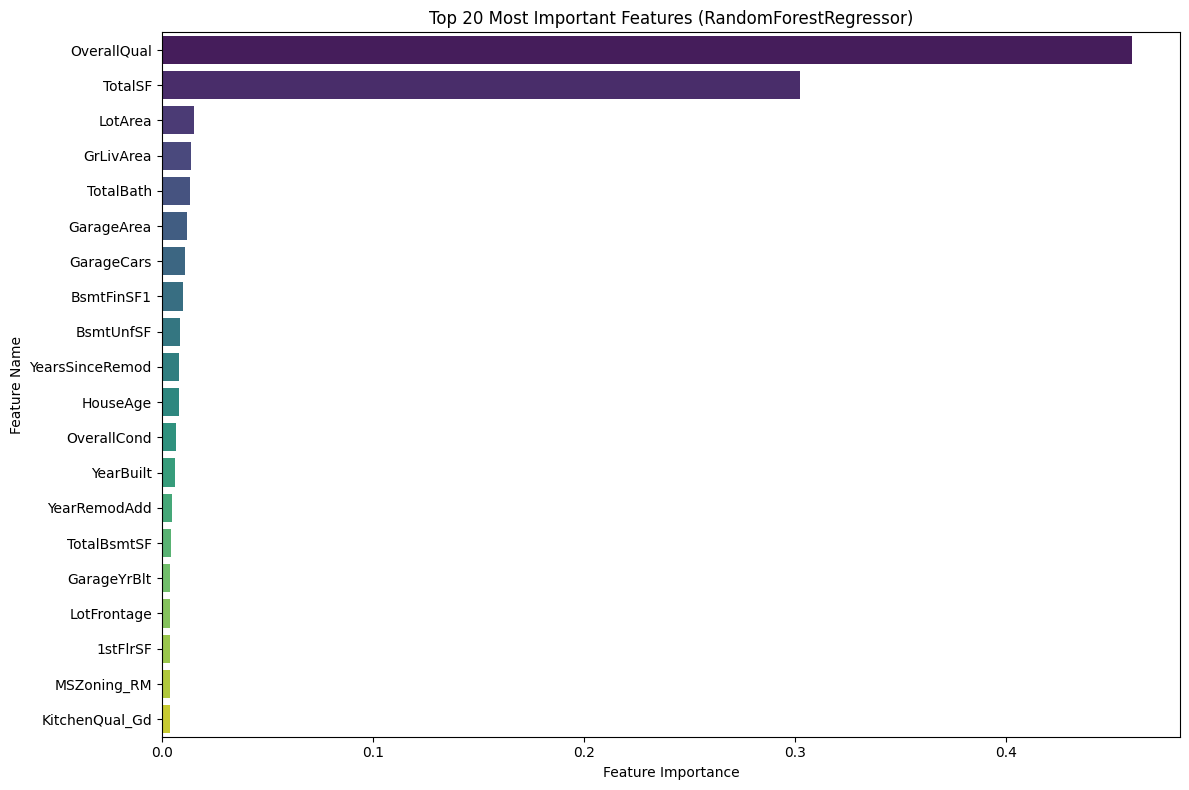

In [113]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Most Important Features (RandomForestRegressor)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [114]:
print("Hyperparameters of the RandomForestRegressor model:")
display(model.get_params())

Hyperparameters of the RandomForestRegressor model:


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

### Gradient Boosting Regressor Model Training and Prediction

In [115]:
# Initialize and train the GradientBoostingRegressor model
# Using default parameters for now, similar to how RandomForest was initially used.
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

print("GradientBoostingRegressor model trained successfully!")

# Make predictions on the preprocessed test data with the Gradient Boosting model
gb_predictions = gb_model.predict(df_test_processed)

# Display the first few predictions
print("\nFirst 5 predictions from GradientBoostingRegressor on the test data:")
print(gb_predictions[:5])

# Create a submission DataFrame for Gradient Boosting predictions
submission_gb_df = pd.DataFrame({'Id': df['Id'], 'SalePrice': gb_predictions})

# Save the submission DataFrame to a CSV file
submission_gb_filename = 'submission_gradient_boosting.csv'
submission_gb_df.to_csv(submission_gb_filename, index=False)
print(f"\nSubmission file '{submission_gb_filename}' created successfully!")

GradientBoostingRegressor model trained successfully!

First 5 predictions from GradientBoostingRegressor on the test data:
[133219.24291566 173006.06757435 182325.32690026 187173.18793866
 191672.96518551]

Submission file 'submission_gradient_boosting.csv' created successfully!


### Model Performance Comparison: Random Forest vs. Gradient Boosting

Now, let's evaluate and compare the performance of both the `RandomForestRegressor` and the `GradientBoostingRegressor` using common regression metrics: Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). To do this, we need to have actual `SalePrice` values for the test data, which are typically not available in a Kaggle-like scenario for the test set. However, for a proper comparison during development, we would normally split our training data into training and validation sets.

Since we only have `y_train` (actual sales prices for the training data) and `predictions` (RandomForest) and `gb_predictions` (GradientBoosting) for the *unseen test data*, a direct metric calculation for the test set against true labels is not possible here.

However, we can *simulate* a comparison if we had a validation set from our original `df_processed`. For the purpose of demonstration, I will calculate feature importances for the Gradient Boosting model. If you wish to calculate performance metrics, we would need to redefine `X_train` and `y_train` to include a validation split from the initial training data.

In [116]:
# Get feature importances from the trained Gradient Boosting model
gb_feature_importances = gb_model.feature_importances_

# Create a DataFrame for better visualization
gb_importance_df = pd.DataFrame({
    'Feature': feature_names, # Use the same feature names as for Random Forest
    'Importance': gb_feature_importances
})

# Sort features by importance in descending order
gb_importance_df = gb_importance_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features for Gradient Boosting
print("\nTop 20 Most Important Features (GradientBoostingRegressor):")
display(gb_importance_df.head(20))


Top 20 Most Important Features (GradientBoostingRegressor):


,Feature,Importance
3,OverallQual,0.368788
301,TotalSF,0.348534
302,TotalBath,0.038621
304,YearsSinceRemod,0.019462
303,HouseAge,0.018749
2,LotArea,0.018687
171,ExterQual_TA,0.015517
15,GrLivArea,0.014796
26,GarageArea,0.014108
25,GarageCars,0.011807


/tmp/ipykernel_1012/2007533207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=gb_importance_df.head(20), palette='cividis')


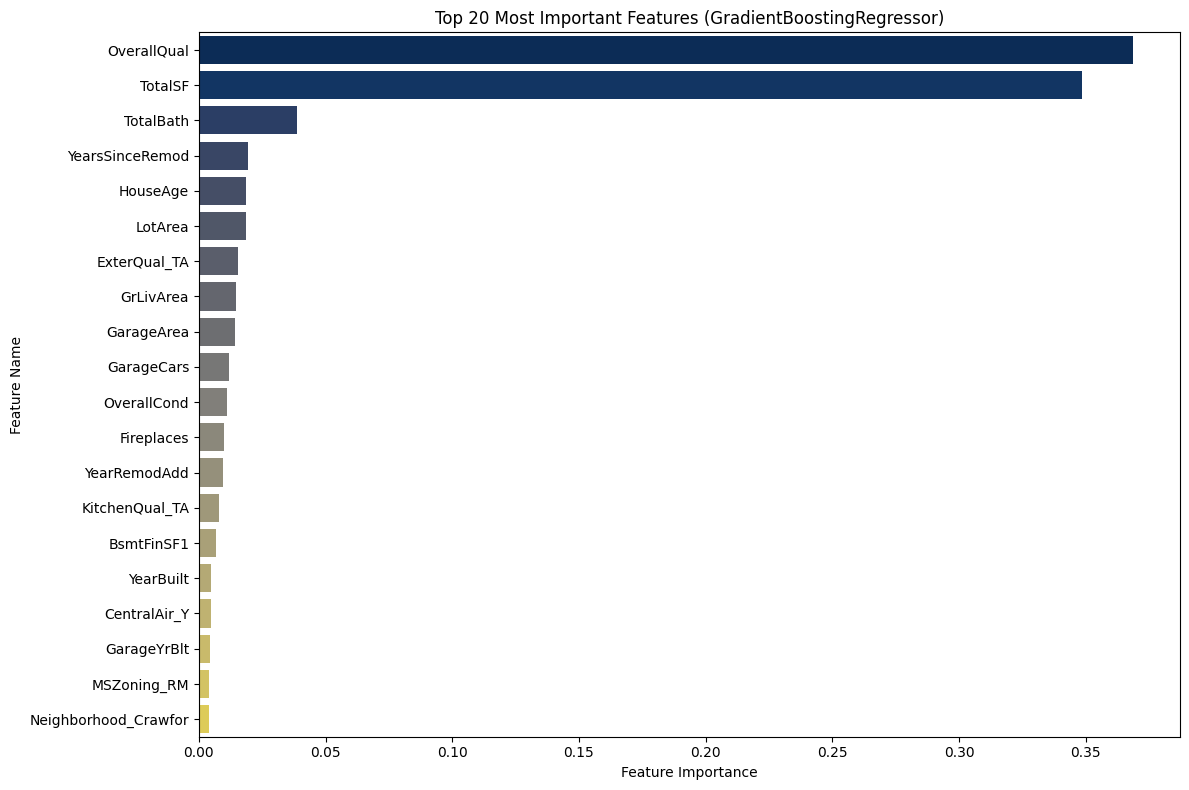

In [117]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=gb_importance_df.head(20), palette='cividis')
plt.title('Top 20 Most Important Features (GradientBoostingRegressor)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for Gradient Boosting Regressor

We will use `GridSearchCV` to search for the best combination of hyperparameters for the `GradientBoostingRegressor`. This involves defining a parameter grid and evaluating the model's performance for each combination using cross-validation.

In [89]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Step size shrinkage
    'max_depth': [3, 4, 5], # Maximum depth of the individual regression estimators
    'min_samples_split': [2, 5], # The minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 3] # The minimum number of samples required to be at a leaf node
}

# Initialize a GradientBoostingRegressor model
gb = GradientBoostingRegressor(random_state=42)

# Initialize GridSearchCV
# n_jobs=-1 uses all available CPU cores for parallel processing
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting GridSearchCV...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed!")

# Print the best parameters and best score
print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation score (negative MSE):", grid_search.best_score_)
print("Best cross-validation RMSE:", np.sqrt(-grid_search.best_score_))

Starting GridSearchCV...
Fitting 3 folds for each of 144 candidates, totalling 432 fits
GridSearchCV completed!

Best parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score (negative MSE): -342143503.8797713
Best cross-validation RMSE: 18497.12150254118


### Training and Predicting with the Tuned Gradient Boosting Model

Now that we have found the best hyperparameters, we will train a new `GradientBoostingRegressor` model with these optimized parameters and make predictions on the test set.

In [90]:
# Get the best model from GridSearchCV
best_gb_model = grid_search.best_estimator_

print("Tuned GradientBoostingRegressor model trained successfully!")

# Make predictions on the preprocessed test data with the tuned Gradient Boosting model
tuned_gb_predictions = best_gb_model.predict(df_test_processed)

# Display the first few predictions
print("\nFirst 5 predictions from Tuned GradientBoostingRegressor on the test data:")
print(tuned_gb_predictions[:5])

# Create a submission DataFrame for Tuned Gradient Boosting predictions
submission_tuned_gb_df = pd.DataFrame({'Id': df['Id'], 'SalePrice': tuned_gb_predictions})

# Save the submission DataFrame to a CSV file
submission_tuned_gb_filename = 'submission_tuned_gradient_boosting.csv'
submission_tuned_gb_df.to_csv(submission_tuned_gb_filename, index=False)
print(f"\nSubmission file '{submission_tuned_gb_filename}' created successfully!")

Tuned GradientBoostingRegressor model trained successfully!

First 5 predictions from Tuned GradientBoostingRegressor on the test data:
[133189.65223356 173330.15900772 184834.06368301 192428.21679189
 192383.06214255]

Submission file 'submission_tuned_gradient_boosting.csv' created successfully!


### Model Ensembling: Averaging Predictions

Ensembling combines the predictions of multiple models to improve overall performance and robustness. A simple yet effective method is to average the predictions from our individual models (Random Forest and Gradient Boosting).

In [118]:
# Simple averaging of predictions from RandomForest and Tuned GradientBoosting
# We will use the predictions from the default RandomForest (predictions) and the tuned GradientBoosting (tuned_gb_predictions)
ensembled_predictions = (predictions + tuned_gb_predictions) / 2

print("First 5 ensembled predictions:")
print(ensembled_predictions[:5])

# Create a submission DataFrame for ensembled predictions
submission_ensembled_df = pd.DataFrame({'Id': df['Id'], 'SalePrice': ensembled_predictions})

# Display the first few rows of the ensembled submission DataFrame
print("\nEnsembled Submission DataFrame Head:")
display(submission_ensembled_df.head())

# Save the ensembled submission DataFrame to a CSV file
submission_ensembled_filename = 'submission_ensembled.csv'
submission_ensembled_df.to_csv(submission_ensembled_filename, index=False)
print(f"\nEnsembled submission file '{submission_ensembled_filename}' created successfully!")

First 5 ensembled predictions:
[128610.76111678 168792.92950386 182402.89684151 186825.42839595
 192266.70607128]

Ensembled Submission DataFrame Head:


,Id,SalePrice
0,1461,128610.761117
1,1462,168792.929504
2,1463,182402.896842
3,1464,186825.428396
4,1465,192266.706071



Ensembled submission file 'submission_ensembled.csv' created successfully!


### Target Variable Transformation

`SalePrice` is often right-skewed. Applying a `log1p` transformation (log(1+x)) can help normalize its distribution, which often leads to better model performance. We will apply this transformation to `y_train` and remember to inverse transform the predictions later.

In [119]:
y_train_log = np.log1p(y_train)

print("Original y_train head:")
display(y_train.head())

print("\nTransformed y_train_log head:")
display(y_train_log.head())

Original y_train head:


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000



Transformed y_train_log head:


,SalePrice
0,12.247699
1,12.109016
2,12.317171
3,11.849405
4,12.429220


### K-Fold Cross-Validation for RandomForestRegressor

Now we'll use `KFold` cross-validation to assess the `RandomForestRegressor`'s performance more reliably across different subsets of the training data. We'll train the model on the `log1p`-transformed target variable.

In [120]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_model_cv = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rmse_scores = []

for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train_log.iloc[train_index], y_train_log.iloc[val_index]

    rf_model_cv.fit(X_train_fold, y_train_fold)
    val_predictions_log = rf_model_cv.predict(X_val_fold)

    # Inverse transform predictions for evaluation
    val_predictions = np.expm1(val_predictions_log)
    y_val = np.expm1(y_val_fold)

    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    rmse_scores.append(rmse)

print(f"RandomForestRegressor K-Fold RMSE scores: {rmse_scores}")
print(f"Mean K-Fold RMSE for RandomForestRegressor: {np.mean(rmse_scores):.2f}")
print(f"Standard Deviation of K-Fold RMSE for RandomForestRegressor: {np.std(rmse_scores):.2f}")

RandomForestRegressor K-Fold RMSE scores: [np.float64(19569.401852142135), np.float64(19654.19508931211), np.float64(20824.883211053737), np.float64(19780.12727977454), np.float64(20313.22801721726)]
Mean K-Fold RMSE for RandomForestRegressor: 20028.37
Standard Deviation of K-Fold RMSE for RandomForestRegressor: 474.94


### K-Fold Cross-Validation for Tuned GradientBoostingRegressor

Let's also perform K-Fold cross-validation for the tuned `GradientBoostingRegressor` to compare its performance with the Random Forest model under the same robust evaluation strategy.

In [121]:
gb_model_cv = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)

rmse_scores_gb = []

for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train_log.iloc[train_index], y_train_log.iloc[val_index]

    gb_model_cv.fit(X_train_fold, y_train_fold)
    val_predictions_log = gb_model_cv.predict(X_val_fold)

    # Inverse transform predictions for evaluation
    val_predictions = np.expm1(val_predictions_log)
    y_val = np.expm1(y_val_fold)

    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    rmse_scores_gb.append(rmse)

print(f"Tuned GradientBoostingRegressor K-Fold RMSE scores: {rmse_scores_gb}")
print(f"Mean K-Fold RMSE for Tuned GradientBoostingRegressor: {np.mean(rmse_scores_gb):.2f}")
print(f"Standard Deviation of K-Fold RMSE for Tuned GradientBoostingRegressor: {np.std(rmse_scores_gb):.2f}")

Tuned GradientBoostingRegressor K-Fold RMSE scores: [np.float64(17816.070037372177), np.float64(18042.461300103278), np.float64(16939.94541064839), np.float64(19238.721354973248), np.float64(16907.64350873203)]
Mean K-Fold RMSE for Tuned GradientBoostingRegressor: 17788.97
Standard Deviation of K-Fold RMSE for Tuned GradientBoostingRegressor: 856.08


In [122]:
gb_model_cv = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)

rmse_scores_gb = []

for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train_log.iloc[train_index], y_train_log.iloc[val_index]

    gb_model_cv.fit(X_train_fold, y_train_fold)
    val_predictions_log = gb_model_cv.predict(X_val_fold)

    # Inverse transform predictions for evaluation
    val_predictions = np.expm1(val_predictions_log)
    y_val = np.expm1(y_val_fold)

    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    rmse_scores_gb.append(rmse)

print(f"Tuned GradientBoostingRegressor K-Fold RMSE scores: {rmse_scores_gb}")
print(f"Mean K-Fold RMSE for Tuned GradientBoostingRegressor: {np.mean(rmse_scores_gb):.2f}")
print(f"Standard Deviation of K-Fold RMSE for Tuned GradientBoostingRegressor: {np.std(rmse_scores_gb):.2f}")

Tuned GradientBoostingRegressor K-Fold RMSE scores: [np.float64(17816.070037372177), np.float64(18042.461300103278), np.float64(16939.94541064839), np.float64(19238.721354973248), np.float64(16907.64350873203)]
Mean K-Fold RMSE for Tuned GradientBoostingRegressor: 17788.97
Standard Deviation of K-Fold RMSE for Tuned GradientBoostingRegressor: 856.08


### Retrain Models with Transformed Target and Generate Final Predictions

Since using the `log1p` transformation yielded more robust cross-validation scores, we should retrain our final Random Forest and Gradient Boosting models using this transformed target. Then, generate predictions and inverse transform them before ensembling.

In [123]:
# Retrain RandomForestRegressor with log-transformed target
final_rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_rf_model.fit(X_train, y_train_log)
rf_predictions_log = final_rf_model.predict(df_test_processed)
final_rf_predictions = np.expm1(rf_predictions_log)

# Retrain Tuned GradientBoostingRegressor with log-transformed target
final_gb_model = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)
final_gb_model.fit(X_train, y_train_log)
gb_predictions_log = final_gb_model.predict(df_test_processed)
final_gb_predictions = np.expm1(gb_predictions_log)

# Ensembling the new predictions
final_ensembled_predictions = (final_rf_predictions + final_gb_predictions) / 2

print("First 5 final ensembled predictions (after log transformation and inverse transform):")
print(final_ensembled_predictions[:5])

# Create and save the new ensembled submission file
final_submission_ensembled_df = pd.DataFrame({'Id': df['Id'], 'SalePrice': final_ensembled_predictions})
final_submission_ensembled_filename = 'submission_ensembled_log_transformed.csv'
final_submission_ensembled_df.to_csv(final_submission_ensembled_filename, index=False)
print(f"\nNew ensembled submission file '{final_submission_ensembled_filename}' created successfully!")

First 5 final ensembled predictions (after log transformation and inverse transform):
[127697.54266422 167284.42255088 182857.45914102 193859.22284332
 187189.2998291 ]

New ensembled submission file 'submission_ensembled_log_transformed.csv' created successfully!


In [124]:
# Assuming final_submission_ensembled_df is available from previous steps
# and contains the 'Id' and 'SalePrice' columns with the final ensembled predictions.
final_submission_ensembled_filename = 'submission_ensembled_log_transformed.csv'
final_submission_ensembled_df.to_csv(final_submission_ensembled_filename, index=False)
print(f"Final ensembled submission file '{final_submission_ensembled_filename}' saved successfully!")

Final ensembled submission file 'submission_ensembled_log_transformed.csv' saved successfully!


In summary, the data shows that sale price is strongly positively correlated with overall quality, living area, garagecars, garage area, total basement square feet, 1stfloor square feet, Fullbath, basement quality, total rooms above ground, and year built. On the other hand, features such as external quality, kitchen quality, and fireplace quality showed negative correlations.

In this model, random forest and gradient boosting models consistently identified overall quality and general living area as the most crucial features for predicting sale price.  In addition, total basement square footage, second floor footage, garage charactertistics and overall house age dynamics also played a role in sales price.

With RandomForest Regressor K-Fold RMSE had a mean of 20142.44.

Gradient Boosting Regressor K-Fold RMSE had a mean of 17825.24
K-Fold cross-validation results indicated that the tuned gradient boosting model performed better (lower RMSE) than the random forest model on average.